# qLDPC basics

This notebook builds a few small codes and inspects the information that qLDPC keeps about them.
It starts with parity-check matrices, moves to logical operators and Tanner graphs, and ends by counting the physical, logical, and gauge qubits of a subsystem code.

The examples are intentionally small.
You can copy each section into a fresh Python file after installing qLDPC.


## Setup

Run the next cell once in a fresh notebook environment.
IPython's `%pip` magic installs into the active kernel, so the following imports use the same environment.


In [1]:
%%capture
%pip install qldpc matplotlib

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.patches import Patch

from qldpc import codes
from qldpc.objects import Pauli

np.set_printoptions(linewidth=100)

## Classical codes start with a parity-check matrix

A binary parity-check matrix $H$ defines the codewords $x$ that satisfy $Hx=0$ modulo 2.
The familiar parameters $[n,k,d]$ count physical bits, encoded bits, and the minimum number of bit flips in a nonzero codeword.

You can use a built-in family or pass your own matrix directly.


In [3]:
ring_code = codes.RingCode(5)
print("ring code parameters:", ring_code.get_code_params())
print("parity-check matrix:")
print(ring_code.matrix)

repetition_code = codes.RepetitionCode(len(ring_code))
assert codes.ClassicalCode.equiv(ring_code, repetition_code)

ring code parameters: (5, 1, 5)
parity-check matrix:
[[1 1 0 0 0]
 [0 1 1 0 0]
 [0 0 1 1 0]
 [0 0 0 1 1]
 [1 0 0 0 1]]


In [4]:
check_matrix = np.array(
    [
        [1, 1, 0],
        [0, 1, 1],
    ]
)
custom_code = codes.ClassicalCode(check_matrix)

assert custom_code.get_code_params() == (3, 1, 3)
print("custom code parameters:", custom_code.get_code_params())

custom code parameters: (3, 1, 3)


A Tanner graph turns the matrix into a bipartite graph.
One set of vertices represents data bits and the other represents parity checks; an edge marks a nonzero matrix entry.
The layout below is only a graph drawing, not a hardware placement.


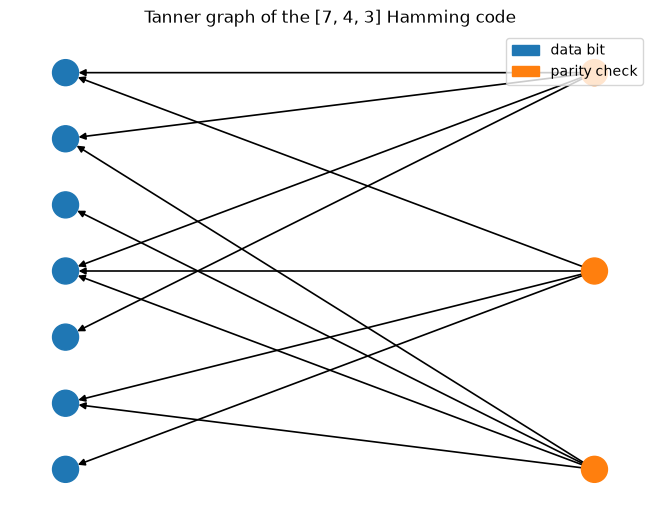

In [5]:
hamming_code = codes.HammingCode(3)
graph = hamming_code.graph
positions = nx.bipartite_layout(
    graph,
    [node for node in graph if node.is_data],
)
colors = ["tab:blue" if node.is_data else "tab:orange" for node in graph]

nx.draw(graph, positions, node_color=colors, node_size=350, width=1.2)
plt.legend(
    handles=[
        Patch(color="tab:blue", label="data bit"),
        Patch(color="tab:orange", label="parity check"),
    ],
    loc="upper right",
)
plt.title("Tanner graph of the [7, 4, 3] Hamming code")
plt.axis("off")
plt.show()

## Quantum checks and logical operators

A qubit stabilizer code stores Pauli operators in symplectic $[X|Z]$ form.
For an ordinary stabilizer code, each independent row fixes the code space.
For a subsystem code, the input rows may instead generate a noncommuting gauge group; the stabilizers are the center of that group.

Quantum parameters are written $[[n,k,d]]$, with $n$ physical qubits, $k$ logical qubits, and distance $d$.


In [6]:
five_qubit_code = codes.FiveQubitCode()
print("five-qubit stabilizers:")
for stabilizer in five_qubit_code.get_strings():
    print(" ", stabilizer)
print("parameters:", five_qubit_code.get_code_params())

five-qubit stabilizers:
  X Z Z X I
  I X Z Z X
  X I X Z Z
  Z X I X Z
parameters: (5, 1, 3)


In [7]:
surface_code = codes.SurfaceCode(3)
logical_x = surface_code.get_logical_ops(Pauli.X)
logical_z = surface_code.get_logical_ops(Pauli.Z)

assert logical_x.shape == logical_z.shape == (surface_code.dimension, len(surface_code))
print("surface-code parameters:", surface_code.get_code_params())
print("support of logical X:", np.flatnonzero(logical_x[0]).tolist())
print("support of logical Z:", np.flatnonzero(logical_z[0]).tolist())

surface-code parameters: (9, 1, 3)
support of logical X: [6, 7, 8]
support of logical Z: [0, 4, 8]


## Build a CSS code from two matrices

A CSS code keeps X-type and Z-type checks in separate matrices.
They are compatible when $H_XH_Z^\mathsf{T}=0$ over the field, which says that every X check commutes with every Z check.

The Hamming matrix is self-orthogonal, so using it in both sectors produces the $[[7,1,3]]$ Steane code.


In [8]:
hamming_matrix = codes.HammingCode(3).matrix
assert not np.any(hamming_matrix @ hamming_matrix.T)

steane_from_matrices = codes.CSSCode(hamming_matrix, hamming_matrix)
assert steane_from_matrices.get_code_params() == (7, 1, 3)
print("matrix-built CSS parameters:", steane_from_matrices.get_code_params())

matrix-built CSS parameters: (7, 1, 3)


## What gauge qubits buy you

A subsystem code stores logical information in only part of its code space.
The remaining encoded degrees of freedom are gauge qubits: changing their state does not change the protected logical state.
This freedom can replace high-weight stabilizer measurements with lower-weight gauge measurements, though a circuit must still infer the stabilizer syndrome from them.

The $3\times3$ Bacon--Shor code has nine physical qubits, one logical qubit, and four gauge qubits.
Its `matrix` contains gauge generators; `get_stabilizer_ops()` computes the commuting stabilizers at the center.


In [9]:
bacon_shor = codes.BaconShorCode(3)

assert bacon_shor.is_subsystem_code
assert (len(bacon_shor), bacon_shor.dimension, bacon_shor.gauge_dimension) == (9, 1, 4)
print("physical qubits:", len(bacon_shor))
print("logical qubits:", bacon_shor.dimension)
print("gauge qubits:", bacon_shor.gauge_dimension)
print("gauge generators supplied:", len(bacon_shor.matrix))
print("independent stabilizers:", len(bacon_shor.get_stabilizer_ops()))

physical qubits: 9
logical qubits: 1
gauge qubits: 4
gauge generators supplied: 12
independent stabilizers: 4


The code object now exposes parity checks or gauge generators, logical operators, distances or bounds, and graph representations through one interface.
The next notebooks use those objects in algebraic constructions, decoders, and noisy circuits.
